# 0.0. Setup

In [1]:
import os
import json
import requests
from pathlib import Path

import re
import pickle
import importlib
import numpy as np
import pandas as pd
import openpyxl as opxl
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any, List

import geopandas as gpd
from shapely.geometry import Point
from difflib import SequenceMatcher
from sklearn.impute import SimpleImputer, KNNImputer

import networkx as nx
from scipy.spatial import cKDTree
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra
from pyproj import Transformer

from matplotlib.colors import Normalize                                                                                                                            
import matplotlib.cm as cm

# None means 'no limit'
pd.set_option('display.max_columns', None)

PROJECT_DIR = Path.cwd().parent
if 'modules' not in os.listdir(Path.cwd()):
    os.chdir(PROJECT_DIR)

DATA_DIR = 'data'
DATA_PUBLIC_DIR = 'data/public'
DATA_PRIVATE_DIR = 'data/private'
DATA_PROCESSED_DIR = 'data/processed'
OUTPUT_DIR = 'output'

# 1.0. Load data

In [ ]:
# Load school information table for joining geographic information of schools
fpath = 'output/processed_project_bukas_school_information.parquet'
sch_info = pd.read_parquet(fpath)
print(sch_info.shape)

In [ ]:
display(sch_info.head(2))

## 1.1. Road network

In [4]:
fname = 'road_network_ncr_region4a.geojson'
fpath = os.path.join(OUTPUT_DIR, fname)
rn = gpd.read_file(fpath)
print(rn.shape)
print(type(rn))

(371831, 6)
<class 'geopandas.geodataframe.GeoDataFrame'>


### Inspect

In [5]:
rn.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
# fig, ax = plt.subplots(figsize=(6,6))

# rn.plot(linewidth=0.2, ax=ax)

# ax.set_aspect("equal")
# ax.axis("off")

# plt.show()
# plt.close()

## 1.2. Distance matrix

In [7]:
# fpath = 'output/school_distance_matrix_long.parquet'
# df_dist = pd.read_parquet(fpath)
# print(df_dist.shape)

In [8]:
# display(df_dist.head())

In [9]:
# mask_both = (
#     (df_dist['school_id_origin'].isin(df_dist['school_id_destination'].unique()))
# )
# df_dist[mask_both & (df_dist['school_id_origin'] == '107904')]

## 1.3. Shapefiles

In [10]:
fpath = 'output/consolidated_geodata_matched.gpkg'
df_shapefiles = gpd.read_file(fpath)
print(df_shapefiles.shape)

(42048, 23)


In [11]:
display(df_shapefiles.head(3))

,psgc_code,corr_code,name,adm4_en_psgc,adm1_pcode,adm2_pcode,adm3_pcode,adm4_pcode,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm1_en,adm2_en,adm3_en,adm4_en_shapes,geo_level,len_crs,area_crs,len_km,area_km2,is_spatially_matched,geometry
0,0102801001,12801001.0,Adams,Adams (Pob.),PH01,PH01028,PH0102801,PH0102801001,0100000000,0102800000,0102801000,0102801001,Region I (Ilocos Region),Ilocos Norte,Adams,Adams,Bgy,45997.0,111184551.0,45.0,111.0,False,"MULTIPOLYGON (((120.92068 18.51462, 120.94626 ..."
1,0102802001,12802001.0,Bani,Bani,PH01,PH01028,PH0102802,PH0102802001,0100000000,0102800000,0102802000,0102802001,Region I (Ilocos Region),Ilocos Norte,Bacarra,Bani,Bgy,5982.0,1761135.0,5.0,1.0,False,"MULTIPOLYGON (((120.61278 18.2759, 120.61282 1..."
2,0102802002,12802002.0,Buyon,Buyon,PH01,PH01028,PH0102802,PH0102802002,0100000000,0102800000,0102802000,0102802002,Region I (Ilocos Region),Ilocos Norte,Bacarra,Buyon,Bgy,9117.0,3875134.0,9.0,3.0,False,"MULTIPOLYGON (((120.62741 18.24638, 120.6337 1..."


### Filter & inspect

In [12]:
df_shapefiles.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

(5732, 23)


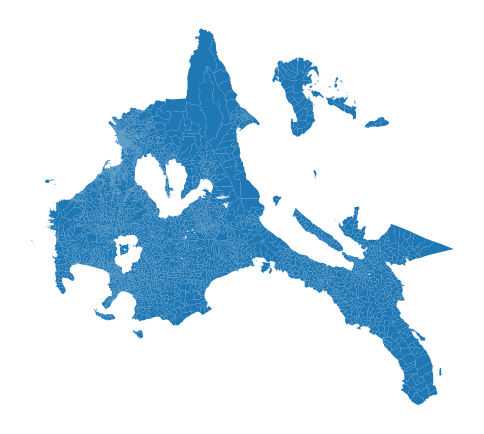

In [13]:
mask = (
    (df_shapefiles['adm1_en'].str.contains(r'calab|NCR', flags=re.IGNORECASE))
    | (df_shapefiles['adm2_en'].str.contains(r'NCR', flags=re.IGNORECASE))
)
df_shp = df_shapefiles.loc[mask].copy()
print(df_shp.shape)

fig, ax = plt.subplots(figsize=(6,6))

df_shp.plot(
    linewidth=0.2,
    ax=ax
)

ax.set_aspect("equal")
ax.axis("off")

plt.show()
plt.close()

In [14]:
# # Inspect NCR only
# mask = df_shapefiles['adm2_en'].str.contains(r'NCR', flags=re.IGNORECASE)
# df_shp = df_shapefiles.loc[mask].copy()
# print(df_shp.shape)

# fig, ax = plt.subplots(figsize=(16,16))

# df_shp.plot(
#     linewidth=0.2,
#     ax=ax
# )

# # A point that's supposedly out-of-bounds (?!)
# ax.scatter(
#     x=120.948531,
#     y=14.658431,
#     marker='o',
#     c='red'
# )

# ax.set_aspect("equal")
# ax.axis("off")

# plt.show()
# plt.close()

## 1.4. Coordinates

In [15]:
%%time
fname = 'all_schools_coordinates_ncr_region4a.parquet'
outpath = os.path.join(OUTPUT_DIR, fname)
sch_coords = pd.read_parquet(outpath)

# Join school information
sch_coords = sch_coords.merge(
    sch_info[['school_id','old_region','province']],
    on='school_id',
    how='left'
)

# Transform to geopandas (?)
sch_coords['geometry'] = sch_coords.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
sch_coords = gpd.GeoDataFrame(sch_coords, geometry='geometry', crs=4326)

print(sch_coords.shape)

(8331, 7)
CPU times: user 91.4 ms, sys: 2.24 ms, total: 93.7 ms
Wall time: 97.4 ms


In [16]:
sch_coords.isna().sum()

school_id     0
longitude     0
latitude      0
sector        0
old_region    0
province      0
geometry      0
dtype: int64

### Inpsect

In [17]:
sch_coords.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [18]:
type(sch_coords)

geopandas.geodataframe.GeoDataFrame

In [19]:
sch_coords['old_region'].unique()

array(['Region IV-A', 'NCR'], dtype=object)

In [20]:
sch_coords['province'].unique()

array(['CAVITE', 'BATANGAS', 'LAGUNA', 'QUEZON', 'RIZAL',
       'NCR SECOND DISTRICT', 'NCR THIRD DISTRICT',
       'MANILA, NCR, FIRST DISTRICT', 'NCR FOURTH DISTRICT'], dtype=object)

In [21]:
display(sch_coords.head())

,school_id,longitude,latitude,sector,old_region,province,geometry
0,107900,120.960226,14.283250,public,Region IV-A,CAVITE,POINT (120.96023 14.28325)
1,107901,120.935551,14.326691,public,Region IV-A,CAVITE,POINT (120.93555 14.32669)
2,107902,120.934790,14.326390,public,Region IV-A,CAVITE,POINT (120.93479 14.32639)
3,107903,120.943507,14.264903,public,Region IV-A,CAVITE,POINT (120.94351 14.2649)
4,107904,120.947710,14.275440,public,Region IV-A,CAVITE,POINT (120.94771 14.27544)


## 1.5. Student flow

In [22]:
fpath = 'output/grade_7_student_flow_table_sy2324.parquet'
flow = pd.read_parquet(fpath)
print(flow.shape)

(288328, 4)


In [23]:
display(flow.head())

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN
1,100000,300388,25.0,NaN
2,100000,305334,1.0,NaN
3,100000,500057,2.0,NaN
4,100001,300002,6.0,NaN


In [24]:
mask = (
    (flow['count_non_beneficiary'] == 0)
    | (flow['count_esc_beneficiary'] == 0)
)
flow[mask]

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary


# 2.0. Verification
I need a way to verify if the values in my distance matrix makes sense.

## 2.1.

In [25]:
# Load distance matrix from notebook 2.2                                                                  
distance_matrix = np.load('output/school_distance_matrix_osrm.npy')                                       
                                                                                                        
with open('output/school_distance_matrix_index.json', 'r') as f:                                          
  index_data = json.load(f)                                                                             
  school_ids = index_data['school_ids']                                                                 
  school_id_to_idx = index_data['school_id_to_idx']                                                     
                                                                                                        
print(f"Distance matrix shape: {distance_matrix.shape}")                                                  
print(f"Schools in matrix: {len(school_ids):,}")                                                          
                                                                                                        
# Load school information                                                                                 
# sch_info = pd.read_parquet('output/processed_project_bukas_school_information.parquet')                   
print(f"\nSchool info shape: {sch_info.shape}")                                                           
                                                                                                        
# Create slim version with just the columns we need                                                       
sch_info_slim = sch_info[['school_id', 'school_name', 'old_region', 'division']].copy()                   
sch_info_slim['school_id'] = sch_info_slim['school_id'].astype(str)                                       
                                                                                                        
print(f"School info slim shape: {sch_info_slim.shape}")                                                   
print(f"\nSample:")                                                                                       
display(sch_info_slim.head())

Distance matrix shape: (8331, 8331)
Schools in matrix: 8,331

School info shape: (61442, 20)
School info slim shape: (61442, 4)

Sample:


,school_id,school_name,old_region,division
0,100001,Apaleng-Libtong ES,Region I,Ilocos Norte
1,100002,Bacarra CES,Region I,Ilocos Norte
2,100003,Buyon ES,Region I,Ilocos Norte
3,100004,Ganagan Elementary School,Region I,Ilocos Norte
4,100005,Macupit ES,Region I,Ilocos Norte


In [48]:
display(flow.head(1))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN


In [49]:
# We'll need to trim our student flow data to only include school IDs in NCR and Region IV
# for origin and destination for our lookup functions to work
processed_flow = flow.copy()
print(flow.shape)

mask = (
    (processed_flow['school_id_origin'].isin(school_ids))
    & (processed_flow['school_id_destination'].isin(school_ids))
)
processed_flow = processed_flow.loc[mask]
print(processed_flow.shape)

(288328, 4)
(57261, 4)


## 2.2.

In [26]:
# =============================================================================                           
# 2.2. Build Verification Lookup Function                                                                 
# =============================================================================                           
                                                                                                        
def lookup_distance(origin_id, dest_id):                                                                  
  """                                                                                                   
  Look up distance between two schools with full context.                                               
                                                                                                        
  Args:                                                                                                 
      origin_id: School ID of origin (string or int)                                                    
      dest_id: School ID of destination (string or int)                                                 
                                                                                                        
  Returns:                                                                                              
      dict with school details and distance, or error message                                           
  """                                                                                                   
  origin_id = str(origin_id)                                                                            
  dest_id = str(dest_id)                                                                                
                                                                                                        
  # Check if schools exist in distance matrix                                                           
  if origin_id not in school_id_to_idx:                                                                 
      return {'error': f'Origin school {origin_id} not in distance matrix'}                             
  if dest_id not in school_id_to_idx:                                                                   
      return {'error': f'Destination school {dest_id} not in distance matrix'}                          
                                                                                                        
  # Get distance from matrix                                                                            
  i = school_id_to_idx[origin_id]                                                                       
  j = school_id_to_idx[dest_id]                                                                         
  dist_m = distance_matrix[i, j]                                                                        
                                                                                                        
  # Get school info for origin                                                                          
  origin_mask = sch_info_slim['school_id'] == origin_id                                                 
  origin_info = sch_info_slim[origin_mask].iloc[0] if origin_mask.sum() > 0 else None                   
                                                                                                        
  # Get school info for destination                                                                     
  dest_mask = sch_info_slim['school_id'] == dest_id                                                     
  dest_info = sch_info_slim[dest_mask].iloc[0] if dest_mask.sum() > 0 else None                         
                                                                                                        
  return {                                                                                              
      'school_id_origin': origin_id,                                                                    
      'school_name_origin': origin_info['school_name'] if origin_info is not None else 'Unknown',       
      'old_region_origin': origin_info['old_region'] if origin_info is not None else 'Unknown',         
      'division_origin': origin_info['division'] if origin_info is not None else 'Unknown',             
      'school_id_destination': dest_id,                                                                 
      'school_name_destination': dest_info['school_name'] if dest_info is not None else 'Unknown',      
      'old_region_destination': dest_info['old_region'] if dest_info is not None else 'Unknown',        
      'division_destination': dest_info['division'] if dest_info is not None else 'Unknown',            
      'distance_m': dist_m,                                                                             
      'distance_km': dist_m / 1000 if dist_m < np.inf else np.inf                                       
  }                                                                                                     
                                                                                                        
                                                                                                        
def display_distance(origin_id, dest_id):                                                                 
  """                                                                                                   
  Display formatted distance lookup result.                                                             
  Pretty-prints the school pair information and distance.                                               
  """                                                                                                   
  result = lookup_distance(origin_id, dest_id)                                                          
                                                                                                        
  if 'error' in result:                                                                                 
      print(f"Error: {result['error']}")                                                                
      return result                                                                                     
                                                                                                        
  print("=" * 70)                                                                                       
  print("ORIGIN SCHOOL")                                                                                
  print(f"  ID:       {result['school_id_origin']}")                                                    
  print(f"  Name:     {result['school_name_origin']}")                                                  
  print(f"  Region:   {result['old_region_origin']}")                                                   
  print(f"  Division: {result['division_origin']}")                                                     
  print()                                                                                               
  print("DESTINATION SCHOOL")                                                                           
  print(f"  ID:       {result['school_id_destination']}")                                               
  print(f"  Name:     {result['school_name_destination']}")                                             
  print(f"  Region:   {result['old_region_destination']}")                                              
  print(f"  Division: {result['division_destination']}")                                                
  print()                                                                                               
  print("DISTANCE (OSRM)")                                                                              
  if result['distance_km'] < np.inf:                                                                    
      print(f"  {result['distance_m']:,.0f} meters ({result['distance_km']:.2f} km)")                   
  else:                                                                                                 
      print("  No route found (unreachable)")                                                           
  print("=" * 70)                                                                                       
                                                                                                        
  return result                                                                                         
                                                                                                        
                                                                                                        
def search_schools(name_pattern):                                                                         
  """                                                                                                   
  Search schools by partial name match.                                                                 
  Useful for finding school IDs when you only know the name.                                            
                                                                                                        
  Args:                                                                                                 
      name_pattern: Partial name to search (case-insensitive)                                           
                                                                                                        
  Returns:                                                                                              
      DataFrame of matching schools                                                                     
  """                                                                                                   
  mask = sch_info_slim['school_name'].str.contains(name_pattern, case=False, na=False)                  
  results = sch_info_slim[mask][['school_id', 'school_name', 'old_region', 'division']]                 
  print(f"Found {len(results)} schools matching '{name_pattern}'")                                      
  return results                                                                                        
                                                                                                        
print("Functions created:")                                                                               
print("  - lookup_distance(origin_id, dest_id) → returns dict with details")                              
print("  - display_distance(origin_id, dest_id) → prints formatted output")                               
print("  - search_schools(name_pattern) → finds schools by partial name")

Functions created:
  - lookup_distance(origin_id, dest_id) → returns dict with details
  - display_distance(origin_id, dest_id) → prints formatted output
  - search_schools(name_pattern) → finds schools by partial name


## 2.3.

In [63]:
display(processed_flow.sample(5))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
63984,109732,305409,1.0,NaN
59556,109385,305303,1.0,NaN
247685,406908,407324,NaN,1.0
205900,136773,305424,53.0,NaN
228840,401988,401905,6.0,NaN


In [75]:
# =============================================================================                           
# 2.3b. Look Up Distances for Test Pairs                                                                  
# =============================================================================                           
                                                                                                        
# Replace these with the actual school IDs from your search results                                       
# Format: (origin_id, dest_id, google_maps_km)                                                            
                                                                                                        
test_pairs = [                                                                                            
    # Pair 4:
    ('108976','301367', 1.5), # from actual GMaps

    # Pair 5:
    ('108527','402714', 7.1), # from actual GMaps

    # Pair 6:
    ('107334','401581', 3.3), # from actual GMaps

    # Pair 7:
    ('136773','305424', 11.1), # from actual GMaps
]                                                                                                         
                                                                                                        
# Look up each pair                                                                                       
print("=" * 70)                                                                                           
print("DISTANCE VERIFICATION: OSRM vs Google Maps")                                                       
print("=" * 70)                                                                                           
                                                                                                        
results = []                                                                                              
for origin_id, dest_id, google_km in test_pairs:                                                          
  if 'REPLACE' in origin_id or 'REPLACE' in dest_id:                                                    
      print(f"\nSkipping placeholder pair - replace with actual IDs")                                   
      continue                                                                                          
                                                                                                        
  print(f"\n")                                                                                          
  result = display_distance(origin_id, dest_id)                                                         
                                                                                                        
  if 'error' not in result:                                                                             
      osrm_km = result['distance_km']                                                                   
      diff_km = osrm_km - google_km                                                                     
      diff_pct = (diff_km / google_km) * 100 if google_km > 0 else 0                                    
                                                                                                        
      print(f"\nCOMPARISON:")                                                                           
      print(f"  Google Maps:  {google_km:.2f} km")                                                      
      print(f"  OSRM:         {osrm_km:.2f} km")                                                        
      print(f"  Difference:   {diff_km:+.2f} km ({diff_pct:+.1f}%)")                                    
                                                                                                        
      results.append({                                                                                  
          'origin': result['school_name_origin'],                                                       
          'destination': result['school_name_destination'],                                             
          'google_km': google_km,                                                                       
          'osrm_km': osrm_km,                                                                           
          'diff_km': diff_km,                                                                           
          'diff_pct': diff_pct                                                                          
      })                                                                                                
                                                                                                        
# Summary table                                                                                           
if results:                                                                                               
  print("\n")                                                                                           
  print("=" * 70)                                                                                       
  print("SUMMARY")                                                                                      
  print("=" * 70)                                                                                       
  summary_df = pd.DataFrame(results)                                                                    
  display(summary_df)

DISTANCE VERIFICATION: OSRM vs Google Maps


ORIGIN SCHOOL
  ID:       108976
  Name:     Polo South Elementary School
  Region:   Region IV-A
  Division: Quezon

DESTINATION SCHOOL
  ID:       301367
  Name:     Pagbilao Grande Island NHS
  Region:   Region IV-A
  Division: Quezon

DISTANCE (OSRM)
  1,546 meters (1.55 km)

COMPARISON:
  Google Maps:  1.50 km
  OSRM:         1.55 km
  Difference:   +0.05 km (+3.0%)


ORIGIN SCHOOL
  ID:       108527
  Name:     Rizal Elementary School
  Region:   Region IV-A
  Division: Quezon

DESTINATION SCHOOL
  ID:       402714
  Name:     Leon Guinto Memorial College
  Region:   Region IV-A
  Division: Quezon

DISTANCE (OSRM)
  6,901 meters (6.90 km)

COMPARISON:
  Google Maps:  7.10 km
  OSRM:         6.90 km
  Difference:   -0.20 km (-2.8%)


ORIGIN SCHOOL
  ID:       107334
  Name:     Tanagan Elementary School
  Region:   Region IV-A
  Division: Batangas

DESTINATION SCHOOL
  ID:       401581
  Name:     Calatagan Institute
  Region:   Region 

,origin,destination,google_km,osrm_km,diff_km,diff_pct
0,Polo South Elementary School,Pagbilao Grande Island NHS,1.5,1.5455,0.0455,3.033333
1,Rizal Elementary School,Leon Guinto Memorial College,7.1,6.9013,-0.1987,-2.798592
2,Tanagan Elementary School,Calatagan Institute,3.3,2.6557,-0.6443,-19.524242
3,CAA Elementary School Main,Paranaque National High School Main,11.1,3.1023,-7.9977,-72.051351


## 2.4. Check Discrepancies
**Notes**
1. [Jan. 25, 2026; 7:30 PM] OSRM routing is effective after GMaps verification. Routing CAA ES to Paranaque NHS using GMaps, for example, will yield weird routing. This seems to be a GMaps problem, where a visualized OSRM routing (2.4d) shows a close approximate of school coordinates and route

In [66]:
# =============================================================================                           
# 2.4. Investigate Distance Discrepancies                                                                 
# =============================================================================                           
                                                                                                        
# Load coordinates data                                                                                   
df_pub = pd.read_parquet('output/processed_public_school_coordinates.parquet')                            
df_priv = pd.read_parquet('output/processed_private_school_coordinates.parquet')                          
                                                                                                        
df_coords = pd.concat([df_pub, df_priv], ignore_index=True)                                               
df_coords['school_id'] = df_coords['school_id'].astype(str)

In [67]:
def investigate_school(school_id):                                                                        
  """Show school details including coordinates for verification."""                                     
  school_id = str(school_id)                                                                            
                                                                                                        
  # Get school info                                                                                     
  info = sch_info_slim[sch_info_slim['school_id'] == school_id]                                         
  coords = df_coords[df_coords['school_id'] == school_id]                                               
                                                                                                        
  if len(info) == 0:                                                                                    
      print(f"School {school_id} not found in info")                                                    
      return                                                                                            
                                                                                                        
  info = info.iloc[0]                                                                                   
                                                                                                        
  print(f"School ID: {school_id}")                                                                      
  print(f"Name: {info['school_name']}")                                                                 
  print(f"Region: {info['old_region']}")                                                                
  print(f"Division: {info['division']}")                                                                
                                                                                                        
  if len(coords) > 0:                                                                                   
      coords = coords.iloc[0]                                                                           
      lat = coords['latitude']                                                                          
      lon = coords['longitude']                                                                         
      print(f"Coordinates: {lat}, {lon}")                                                               
      print(f"Google Maps: https://www.google.com/maps?q={lat},{lon}")                                  
  else:                                                                                                 
      print("Coordinates: NOT FOUND")                                                                   
  print()

In [68]:
# Investigate the problematic schools                                                                     
print("=" * 70)                                                                                           
print("INVESTIGATING DISCREPANCIES")                                                                      
print("=" * 70)                                                                                           
                                                                                                        
# Pair 1: Polo South ES → Pagbilao Grande Island NHS (90% difference)                                     
print("\n--- PAIR 1: 90% difference ---")                                                                 
investigate_school('108976')  # Polo South ES                                                             
investigate_school('301367')  # Pagbilao Grande Island NHS                                                
                                                                                                        
# Pair 4: CAA ES → Paranaque NHS (72% difference)                                                         
print("\n--- PAIR 4: 72% difference ---")                                                                 
investigate_school('136773')  # CAA ES                                                                    
investigate_school('305424')  # Paranaque NHS

INVESTIGATING DISCREPANCIES

--- PAIR 1: 90% difference ---
School ID: 108976
Name: Polo South Elementary School
Region: Region IV-A
Division: Quezon
Coordinates: 13.9097157, 121.7555316
Google Maps: https://www.google.com/maps?q=13.9097157,121.7555316

School ID: 301367
Name: Pagbilao Grande Island NHS
Region: Region IV-A
Division: Quezon
Coordinates: 13.9160101, 121.7647523
Google Maps: https://www.google.com/maps?q=13.9160101,121.7647523


--- PAIR 4: 72% difference ---
School ID: 136773
Name: CAA Elementary School Main
Region: NCR
Division: Las Piñas City
Coordinates: 14.4603493, 120.9992558
Google Maps: https://www.google.com/maps?q=14.4603493,120.9992558

School ID: 305424
Name: Paranaque National High School Main
Region: NCR
Division: Paranaque City
Coordinates: 14.4794677, 120.9989294
Google Maps: https://www.google.com/maps?q=14.4794677,120.9989294



### 2.4b Check straight-line

In [69]:
# =============================================================================                           
# 2.4b. Compare OSRM vs Straight-Line (Haversine) Distance                                                
# =============================================================================                           
                                                                                                        
from math import radians, sin, cos, sqrt, atan2                                                           
                                                                                                        
def haversine_distance(lat1, lon1, lat2, lon2):                                                           
  """Calculate straight-line distance between two points in meters."""                                  
  R = 6_371_000  # Earth radius in meters                                                               
                                                                                                        
  lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])                                       
                                                                                                        
  dlat = lat2 - lat1                                                                                    
  dlon = lon2 - lon1                                                                                    
                                                                                                        
  a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2                                           
  c = 2 * atan2(sqrt(a), sqrt(1-a))                                                                     
                                                                                                        
  return R * c                                                                                          
                                                                                                        
def compare_distances(origin_id, dest_id, google_km=None):                                                
  """Compare OSRM distance vs straight-line distance."""                                                
  origin_id = str(origin_id)                                                                            
  dest_id = str(dest_id)                                                                                
                                                                                                        
  # Get coordinates                                                                                     
  origin_coords = df_coords[df_coords['school_id'] == origin_id]                                        
  dest_coords = df_coords[df_coords['school_id'] == dest_id]                                            
                                                                                                        
  if len(origin_coords) == 0 or len(dest_coords) == 0:                                                  
      print("Coordinates not found")                                                                    
      return                                                                                            
                                                                                                        
  origin_coords = origin_coords.iloc[0]                                                                 
  dest_coords = dest_coords.iloc[0]                                                                     
                                                                                                        
  # Calculate straight-line distance                                                                    
  straight_m = haversine_distance(                                                                      
      origin_coords['latitude'], origin_coords['longitude'],                                            
      dest_coords['latitude'], dest_coords['longitude']                                                 
  )                                                                                                     
  straight_km = straight_m / 1000                                                                       
                                                                                                        
  # Get OSRM distance                                                                                   
  result = lookup_distance(origin_id, dest_id)                                                          
  osrm_km = result['distance_km']                                                                       
                                                                                                        
  # Get school names                                                                                    
  origin_name = result['school_name_origin']                                                            
  dest_name = result['school_name_destination']                                                         
                                                                                                        
  print(f"Origin: {origin_name}")                                                                       
  print(f"Destination: {dest_name}")                                                                    
  print()                                                                                               
  print(f"  Straight-line:  {straight_km:.2f} km")                                                      
  print(f"  OSRM:           {osrm_km:.2f} km")                                                          
  if google_km:                                                                                         
      print(f"  Google Maps:    {google_km:.2f} km")                                                    
  print()                                                                                               
                                                                                                        
  # Check if OSRM ≈ straight-line (within 10%)                                                          
  if osrm_km < np.inf:                                                                                  
      ratio = osrm_km / straight_km                                                                     
      if ratio < 1.1:                                                                                   
          print(f"  ⚠️  OSRM ≈ straight-line (ratio: {ratio:.2f})")                                     
          print(f"      This suggests OSRM found no valid road route!")                                 
      else:                                                                                             
          print(f"  ✓  OSRM > straight-line (ratio: {ratio:.2f}) - valid road route")                   
  else:                                                                                                 
      print(f"  ⚠️  OSRM returned no route (inf)")                                                      
                                                                                                        
  print()                                                                                               
  return {'straight_km': straight_km, 'osrm_km': osrm_km, 'google_km': google_km}                       
                                                                                                        
# Test the problematic pairs                                                                              
print("=" * 70)                                                                                           
print("PAIR 1: Polo South ES → Pagbilao Grande Island NHS")                                               
print("=" * 70)                                                                                           
compare_distances('108976', '301367', google_km=15.5)                                                     
                                                                                                        
print("=" * 70)                                                                                           
print("PAIR 4: CAA ES → Paranaque NHS")                                                                   
print("=" * 70)                                                                                           
compare_distances('136773', '305424', google_km=11.1)

PAIR 1: Polo South ES → Pagbilao Grande Island NHS
Origin: Polo South Elementary School
Destination: Pagbilao Grande Island NHS

  Straight-line:  1.22 km
  OSRM:           1.55 km
  Google Maps:    15.50 km

  ✓  OSRM > straight-line (ratio: 1.27) - valid road route

PAIR 4: CAA ES → Paranaque NHS
Origin: CAA Elementary School Main
Destination: Paranaque National High School Main

  Straight-line:  2.13 km
  OSRM:           3.10 km
  Google Maps:    11.10 km

  ✓  OSRM > straight-line (ratio: 1.46) - valid road route



{'straight_km': 2.126159538043527,
 'osrm_km': np.float64(3.1023),
 'google_km': 11.1}

### 2.4c Route details

In [71]:
def get_osrm_route_details(origin_id, dest_id):                                                           
  """                                                                                                   
  Get detailed route from OSRM including the actual path taken.                                         
  Uses Route API instead of Table API.                                                                  
  """                                                                                                   
  origin_id = str(origin_id)                                                                            
  dest_id = str(dest_id)                                                                                
                                                                                                        
  # Get coordinates                                                                                     
  origin_row = df_coords[df_coords['school_id'] == origin_id].iloc[0]                                   
  dest_row = df_coords[df_coords['school_id'] == dest_id].iloc[0]                                       
                                                                                                        
  origin_coord = f"{origin_row['longitude']},{origin_row['latitude']}"                                  
  dest_coord = f"{dest_row['longitude']},{dest_row['latitude']}"                                        
                                                                                                        
  # Query OSRM Route API                                                                                
  url = f"http://osrm:5000/route/v1/driving/{origin_coord};{dest_coord}"                                
  params = {                                                                                            
      'overview': 'full',      # Get full route geometry                                                
      'geometries': 'geojson', # Return as GeoJSON                                                      
      'steps': 'true'          # Include turn-by-turn directions                                        
  }                                                                                                     
                                                                                                        
  response = requests.get(url, params=params)                                                           
  data = response.json()                                                                                
                                                                                                        
  if data['code'] != 'Ok':                                                                              
      print(f"Error: {data.get('message', 'Unknown error')}")                                           
      return None                                                                                       
                                                                                                        
  route = data['routes'][0]                                                                             
                                                                                                        
  print("=== OSRM Route Details ===")                                                                   
  print(f"Distance: {route['distance']/1000:.2f} km")                                                   
  print(f"Duration: {route['duration']/60:.1f} minutes")                                                
  print(f"\nRoute steps:")                                                                              
                                                                                                        
  for i, leg in enumerate(route['legs']):                                                               
      for j, step in enumerate(leg['steps']):                                                           
          road_name = step.get('name', 'unnamed')                                                       
          road_ref = step.get('ref', '')                                                                
          distance = step['distance']                                                                   
          maneuver = step['maneuver']['type']                                                           
                                                                                                        
          if distance > 10:  # Skip very short segments                                                 
              print(f"  {j+1}. {maneuver}: {road_name} {road_ref} ({distance:.0f}m)")                   
                                                                                                        
  return data

In [ ]:
test_pairs = [                                                                                            
    # Pair 4:
    ('108976','301367', 15.5), # from actual GMaps
    # Pair 5:
    ('108527','402714', 7.1), # from actual GMaps
    # Pair 6:
    ('107334','401581', 3.3), # from actual GMaps
    # Pair 7:
    ('136773','305424', 11.1), # from actual GMaps
]

In [77]:
# Test with Pair 1 (Polo South ES → Pagbilao Grande Island NHS)                                           
# Replace with actual school IDs from your verification                                                   
pair1_origin = "136773"                                                            
pair1_dest = "305424"                                             
                                                                                                        
route_data = get_osrm_route_details(pair1_origin, pair1_dest)

=== OSRM Route Details ===
Distance: 3.10 km
Duration: 5.0 minutes

Route steps:
  1. depart:   (89m)
  2. turn: Narra Street  (66m)
  3. turn: Bagong Lipunan Street  (256m)
  4. turn: Kalamansi Street  (44m)
  5. turn: Green Revolution Street  (116m)
  6. end of road: CAA Road  (275m)
  7. new name: J. Tionquiao Street  (1096m)
  8. turn: Angelina Canaynay Avenue  (570m)
  9. end of road: Dr. A. Santos Avenue 63 (497m)
  10. turn: Kay Talise Street  (94m)


### 2.4d Viz OSRM Route

In [73]:
# Section 2.4d - Visualize OSRM Route on Map                                                              
import folium                                                                                             
from shapely.geometry import shape                                                                        
                                                                                                        
def visualize_osrm_route(origin_id, dest_id):                                                             
  """                                                                                                   
  Visualize the OSRM route on an interactive map.                                                       
  """                                                                                                   
  origin_id = str(origin_id)                                                                            
  dest_id = str(dest_id)                                                                                
                                                                                                        
  # Get coordinates                                                                                     
  origin_row = df_coords[df_coords['school_id'] == origin_id].iloc[0]                                   
  dest_row = df_coords[df_coords['school_id'] == dest_id].iloc[0]                                       
                                                                                                        
  origin_coord = f"{origin_row['longitude']},{origin_row['latitude']}"                                  
  dest_coord = f"{dest_row['longitude']},{dest_row['latitude']}"                                        
                                                                                                        
  # Query OSRM Route API                                                                                
  url = f"http://osrm:5000/route/v1/driving/{origin_coord};{dest_coord}"                                
  params = {                                                                                            
      'overview': 'full',                                                                               
      'geometries': 'geojson',                                                                          
      'steps': 'true'                                                                                   
  }                                                                                                     
                                                                                                        
  response = requests.get(url, params=params)                                                           
  data = response.json()                                                                                
                                                                                                        
  if data['code'] != 'Ok':                                                                              
      print(f"Error: {data.get('message', 'Unknown error')}")                                           
      return None                                                                                       
                                                                                                        
  route = data['routes'][0]                                                                             
  route_geom = route['geometry']                                                                        
                                                                                                        
  # Create map centered on midpoint                                                                     
  center_lat = (origin_row['latitude'] + dest_row['latitude']) / 2                                      
  center_lon = (origin_row['longitude'] + dest_row['longitude']) / 2                                    
                                                                                                        
  m = folium.Map(location=[center_lat, center_lon], zoom_start=14)                                      
                                                                                                        
  # Add route line (RED)                                                                                
  folium.GeoJson(                                                                                       
      route_geom,                                                                                       
      style_function=lambda x: {'color': 'red', 'weight': 4, 'opacity': 0.8}                            
  ).add_to(m)                                                                                           
                                                                                                        
  # Add origin marker (GREEN)                                                                           
  folium.Marker(                                                                                        
      [origin_row['latitude'], origin_row['longitude']],                                                
      popup=f"Origin: {origin_id}",                                                                     
      icon=folium.Icon(color='green', icon='play')                                                      
  ).add_to(m)                                                                                           
                                                                                                        
  # Add destination marker (RED)                                                                        
  folium.Marker(                                                                                        
      [dest_row['latitude'], dest_row['longitude']],                                                    
      popup=f"Destination: {dest_id}",                                                                  
      icon=folium.Icon(color='red', icon='stop')                                                        
  ).add_to(m)                                                                                           
                                                                                                        
  # Add tile layer options                                                                              
  folium.TileLayer('OpenStreetMap').add_to(m)                                                           
  folium.TileLayer(                                                                                     
      'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',                                             
      attr='Google Satellite',                                                                          
      name='Google Satellite'                                                                           
  ).add_to(m)                                                                                           
  folium.LayerControl().add_to(m)                                                                       
                                                                                                        
  print(f"Route distance: {route['distance']/1000:.2f} km")                                             
  print(f"Route coordinates: {len(route_geom['coordinates'])} points")                                  
                                                                                                        
  return m

In [76]:
# Visualize Pair 1 route                                                                                  
pair1_origin = "136773"                                                            
pair1_dest = "305424"                                                  
                                                                                                        
route_map = visualize_osrm_route(pair1_origin, pair1_dest)                                                
route_map  # Display in notebook

Route distance: 3.10 km
Route coordinates: 103 points


# 3.0. Scratch

In [78]:
fpath = os.path.join(OUTPUT_DIR, 'scratch','od_pairs_without_distance_data.parquet')
df_od = pd.read_parquet(fpath)
print(df_od.shape)

(20818, 2)


In [79]:
display(df_od.head())

,origin_school_id,destination_school_id
0,100047,401984
1,100063,403070
2,100167,402254
3,100326,424131
4,100328,402305


In [83]:
og_id, dest_id = '100047', '401984'
route_data_a = get_osrm_route_details(og_id, dest_id)

=== OSRM Route Details ===
Distance: 578.24 km
Duration: 593.7 minutes

Route steps:
  1. depart: M. Agullana Street  (27m)
  2. turn: C. Torres Street  (484m)
  3. end of road: M. Garvida Street  (200m)
  4. turn: Bangui Bypass Road  (1240m)
  5. end of road: Manila North Road 1 (9376m)
  6. new name: National Highway 1 1 (16632m)
  7. new name: Maharlika Highway 1 (17226m)
  8. new name: Manila North Road 1 (1613m)
  9. turn: Pasuquin Diversion Road  (2471m)
  10. end of road: Manila North Road 1 (12236m)
  11. new name: General Segundo Avenue 1 (3987m)
  12. end of road: J. P. Rizal Avenue 1 (107m)
  13. off ramp:   (51m)
  14. merge: Manila North Road 1 (41764m)
  15. new name: Route 2 2 (7452m)
  16. new name: National Highway 2 2 (4762m)
  17. continue: National Highway 2 2 (5247m)
  18. turn: Municipal Road  (929m)
  19. turn:   (74m)
  20. turn:   (230m)
  21. merge: Route 2 2 (14007m)
  22. turn: Bantay-Vigan-San Ildefonso Bypass Road  (11024m)
  23. end of road: Route 2 2 (29

In [84]:
route_map_a = visualize_osrm_route(og_id, dest_id)                                                
route_map_a

TypeError: unsupported operand type(s) for +: 'float' and 'str'

In [85]:
test_pairs = [                                                                                            
    # Pair 4:
    ('100047','401984', 0.0),
]                                                                                                         
                                                                                                        
# Look up each pair                                                                                       
print("=" * 70)                                                                                           
print("DISTANCE VERIFICATION: OSRM vs Google Maps")                                                       
print("=" * 70)                                                                                           
                                                                                                        
results = []                                                                                              
for origin_id, dest_id, google_km in test_pairs:                                                          
  if 'REPLACE' in origin_id or 'REPLACE' in dest_id:                                                    
      print(f"\nSkipping placeholder pair - replace with actual IDs")                                   
      continue                                                                                          
                                                                                                        
  print(f"\n")                                                                                          
  result = display_distance(origin_id, dest_id)                                                         
                                                                                                        
  if 'error' not in result:                                                                             
      osrm_km = result['distance_km']                                                                   
      diff_km = osrm_km - google_km                                                                     
      diff_pct = (diff_km / google_km) * 100 if google_km > 0 else 0                                    
                                                                                                        
      print(f"\nCOMPARISON:")                                                                           
      print(f"  Google Maps:  {google_km:.2f} km")                                                      
      print(f"  OSRM:         {osrm_km:.2f} km")                                                        
      print(f"  Difference:   {diff_km:+.2f} km ({diff_pct:+.1f}%)")                                    
                                                                                                        
      results.append({                                                                                  
          'origin': result['school_name_origin'],                                                       
          'destination': result['school_name_destination'],                                             
          'google_km': google_km,                                                                       
          'osrm_km': osrm_km,                                                                           
          'diff_km': diff_km,                                                                           
          'diff_pct': diff_pct                                                                          
      })                                                                                                
                                                                                                        
# Summary table                                                                                           
if results:                                                                                               
  print("\n")                                                                                           
  print("=" * 70)                                                                                       
  print("SUMMARY")                                                                                      
  print("=" * 70)                                                                                       
  summary_df = pd.DataFrame(results)                                                                    
  display(summary_df)

DISTANCE VERIFICATION: OSRM vs Google Maps


Error: Origin school 100047 not in distance matrix


In [87]:
lst_ids = ['100047','401984']
sch_coords[sch_coords['school_id'].isin(lst_ids)]

,school_id,longitude,latitude,sector,old_region,province,geometry
7603,401984,120.923795,14.35379,private,Region IV-A,CAVITE,POINT (120.92379 14.35379)
